In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [2]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

In [3]:
lista_alumnos_df = pd.DataFrame(lista_alumnos, columns=["Nombre", "Edad", "Altura"])
lista_alumnos_df.head()

,Nombre,Edad,Altura
0,Leonardo S,24,1.82
1,Piero T,25,1.71
2,Marta B,35,1.66
3,Silvia P,37,1.63
4,Faro Z,29,1.90


In [4]:
lista_alumnos_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Nombre  21 non-null     str    
 1   Edad    21 non-null     int64  
 2   Altura  21 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 636.0 bytes


In [5]:
lista_alumnos_df.describe()

,Edad,Altura
count,21.000000,21.000000
mean,32.095238,1.727143
std,6.081980,0.079003
min,23.000000,1.600000
25%,27.000000,1.660000
50%,32.000000,1.720000
75%,36.000000,1.800000
max,45.000000,1.900000


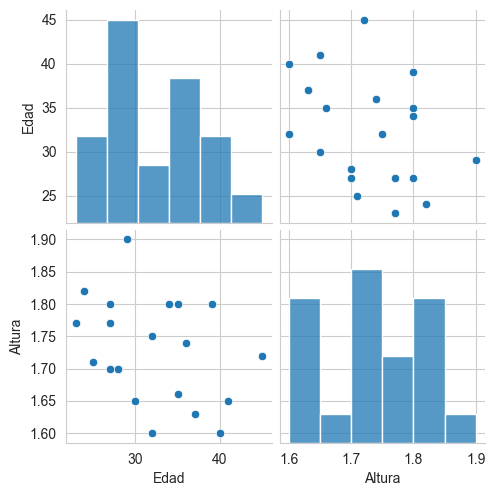

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

sns.pairplot(lista_alumnos_df);

In [7]:
lista_alumnos_df.corr(numeric_only=True)

,Edad,Altura
Edad,1.000000,-0.329275
Altura,-0.329275,1.000000


### Conclusión del análisis exploratorio

La correlación entre Edad y Altura es de **-0.33**, lo cual indica una relación **débil y negativa**. Esto significa que la regresión lineal no es una técnica muy adecuada para predecir la altura a partir de la edad en este dataset, ya que la edad explica muy poco de la varianza en la altura.

Aun así, entrenamos el modelo para ver qué errores comete.

### Entrena un modelo de regresión lineal

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [9]:
# Variable(s) predictora(s) (Feature) → X
X = lista_alumnos_df[['Edad']]

# Variable objetivo (Target) → y
y = lista_alumnos_df['Altura']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Total samples:", X.shape[0])
print("Train samples:", X_train.shape[0])
print("Test  samples:", X_test.shape[0])

Total samples: 21
Train samples: 16
Test  samples: 5


In [10]:
# Crear y entrenar el modelo
lm = LinearRegression()
lm.fit(X_train, y_train)

print("Intercepto (a):", lm.intercept_)
print("Coeficiente (b):", lm.coef_[0])
print()
print(f"Fórmula: Altura = {lm.intercept_:.4f} + {lm.coef_[0]:.6f} * Edad")

Intercepto (a): 1.858051298091961
Coeficiente (b): -0.004357209884266498

Fórmula: Altura = 1.8581 + -0.004357 * Edad


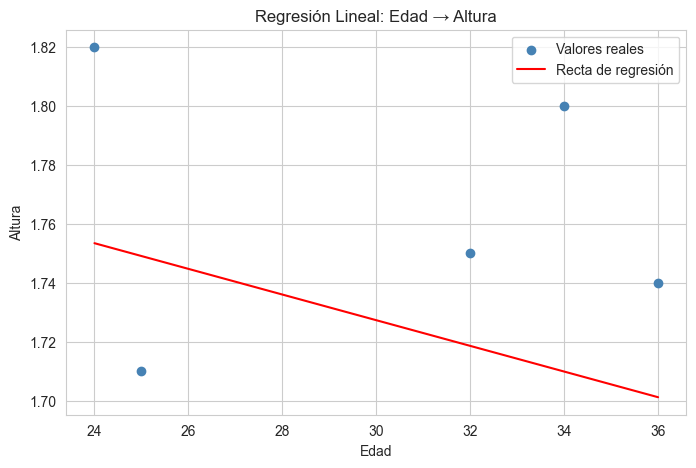

In [11]:
# Predicciones sobre el conjunto de test
predictions = lm.predict(X_test)

# Visualización: valores reales vs predichos
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='steelblue', label='Valores reales')
plt.plot(X_test.sort_values('Edad'), lm.predict(X_test.sort_values('Edad')), color='red', label='Recta de regresión')
plt.xlabel('Edad')
plt.ylabel('Altura')
plt.title('Regresión Lineal: Edad → Altura')
plt.legend()
plt.show()

### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [12]:
import numpy as np

# --- CÁLCULO MANUAL DE LOS ERRORES ---

# Residuos = diferencia entre valor real y predicción
residuos = y_test.values - predictions

# MAE (Mean Absolute Error) → promedio del valor absoluto de los residuos
mae_manual = np.mean(np.abs(residuos))

# MAPE (Mean Absolute Percentage Error) → error porcentual medio
mape_manual = np.mean(np.abs(residuos / y_test.values)) * 100

# MSE (Mean Squared Error) → promedio del cuadrado de los residuos
mse_manual = np.mean(residuos ** 2)

# RMSE (Root Mean Squared Error) → raíz del MSE
rmse_manual = np.sqrt(mse_manual)

print("=== Errores calculados MANUALMENTE ===")
print(f"MAE  (Error Absoluto Medio):           {mae_manual:.4f} m")
print(f"MAPE (Error Absoluto Porcentual Medio): {mape_manual:.2f} %")
print(f"MSE  (Error Cuadrático Medio):          {mse_manual:.6f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_manual:.4f} m")

=== Errores calculados MANUALMENTE ===
MAE  (Error Absoluto Medio):           0.0532 m
MAPE (Error Absoluto Porcentual Medio): 2.99 %
MSE  (Error Cuadrático Medio):          0.003313
RMSE (Raíz del Error Cuadrático Medio): 0.0576 m


In [ ]:
from sklearn import metrics

# --- CÁLCULO CON SKLEARN ---
print("=== Errores calculados con sklearn ===")
print(f"MAE  (Error Absoluto Medio):           {metrics.mean_absolute_error(y_test, predictions):.4f} m")
print(f"MAPE (Error Absoluto Porcentual Medio): {metrics.mean_absolute_percentage_error(y_test, predictions)*100:.2f} %")
print(f"MSE  (Error Cuadrático Medio):          {metrics.mean_squared_error(y_test, predictions):.6f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {np.sqrt(metrics.mean_squared_error(y_test, predictions)):.4f} m")
print()
print(f"R2 Score: {lm.score(X_test, y_test):.4f}")
print()
print("Interpretación: el modelo comete un error medio de unos pocos centímetros,")
print("pero el R² bajo confirma que la edad no es un buen predictor de la altura en este grupo.")

=== Errores calculados con sklearn ===
MAE  (Error Absoluto Medio):           0.0532 m
MAPE (Error Absoluto Porcentual Medio): 2.99 %
MSE  (Error Cuadrático Medio):          0.003313
RMSE (Raíz del Error Cuadrático Medio): 0.0576 m

R² Score: -1.0398

Interpretación: el modelo comete un error medio de unos pocos centímetros,
pero el R² bajo confirma que la edad no es un buen predictor de la altura en este grupo.
